In [1]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.fft import fft
import pandas as pd
from scipy import signal
import seaborn as sns
from scipy.special import comb
sns.set()

# 11章演習問題

## (1)

### (a) 遮断周波数$\omega_c=\pi/2$の1次低域フィルタ

$\tan \omega_c/2=1$

Nが奇数なので，式(11.13)から
\begin{align*}
q_0 &= \exp(j0) = 1,\\
q_1 &= \exp(j\pi) = -1
\end{align*}

式(11.15)から極$p_k$は，$p_0=1$，$p_1=0$．絶対値が1の極を用いて，

\begin{align*}
H(z) &= \frac{1}{2}(1+z^{-1})
\end{align*}

振幅特性は

\begin{align*}
H(e^{j\omega}) &= \frac{1}{2}(1+e^{-j\omega})\\
&= e^{-j\omega/2}\cos\omega\\
|H(e^{j\omega})| &= |\cos\omega/2|
\end{align*}

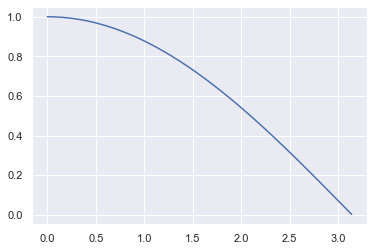

In [6]:
omega = np.linspace(0, np.pi, 1024, endpoint=False)
plt.plot(omega, np.abs(np.cos(omega/2)))
plt.show()

### (d) 遮断周波数$\omega_c=\pi/3$の２次低域フィルタ

In [11]:
omegac = np.pi / 3.0
tc = np.tan(omegac / 2.0)
print(tc)

0.5773502691896256


In [21]:
N = 2
q = []
for k in range(2*N):
    pw = (2.0 * k + 1.0) * np.pi / (2.0 * N)
    q.append( tc * np.exp(np.complex(0.0, pw)) )
print(q)

[(0.40824829046386296+0.40824829046386285j), (-0.40824829046386285+0.40824829046386296j), (-0.408248290463863-0.40824829046386285j), (0.40824829046386285-0.408248290463863j)]


In [20]:
p = []
for k in range(2*N):
    p.append( (1.0 + q[k]) / (1.0 - q[k]) )
print(p)
print(np.abs(p))

[(1.2898979485566362+1.5797958971132706j), (0.3101020514433645+0.3797958971132713j), (0.31010205144336445-0.37979589711327105j), (1.2898979485566353-1.5797958971132706j)]
[2.03950773 0.49031439 0.49031439 2.03950773]


In [23]:
K = 1.0 / (2.0**N) * np.abs((1.0 - p[1]) * (1.0 - p[2]))
print(K)

0.15505102572168214


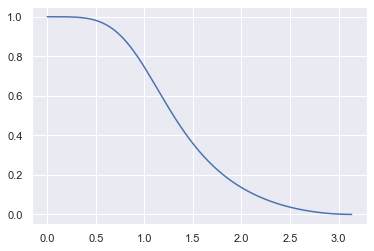

In [27]:
w, H0 = signal.freqz(b=[1.0, 1.0], a=[1.0, -p[1]])
_, H1 = signal.freqz(b=[1.0, 1.0], a=[1.0, -p[2]])
H = K * H0 * H1
plt.plot(w, np.abs(H))

## (2)

N=4
p=[0.68288035 0.25414101 0.25414101 0.68288035]
K=0.04658290663644367


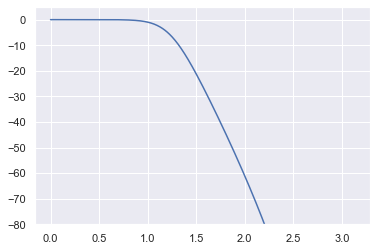

In [82]:
omegac = 0.4 * np.pi
omegas = 0.6 * np.pi
As = 20.0

tc = np.tan(omegac/2.0)
ts = np.tan(omegas/2.0)
num = np.log(10**(As/10.0) - 1.0)
den = np.log(ts/tc)

N = int(np.ceil(num/den/2.0))
print(f"N={N}")

q = []
for k in range(2*N):
    pw = (2.0 * k + 1.0) * np.pi / (2.0 * N)
    q.append( tc * np.exp(np.complex(0.0, pw)) )

p = []
for k in range(2*N):
    pk = (1.0 + q[k]) / (1.0 - q[k])
    if np.abs(pk) < 1.0:
        p.append(pk)
print(f"p={np.abs(p)}")

K = 1.0 / (2.0**N)
for pk in p:
    K *= np.abs((1.0 - pk))
print(f"K={K}")

H = K
for pk in p:
    w, Hk = signal.freqz(b=[1.0, 1.0], a=[1.0, -pk])
    H *= Hk

plt.plot(w, 20.0 * np.log(np.abs(H)))
plt.ylim(-80, 5.0)
plt.show()

## (3)

式(11.16)を周波数変換して整理する．
\begin{align*}
H_h(Z) &= K\frac{(1-\alpha-(1-\alpha)Z^{-1})^N}{\Pi_{|p_k|<1}(1+\alpha p_k + (p_k + \alpha)Z^{-1})}
\end{align*}

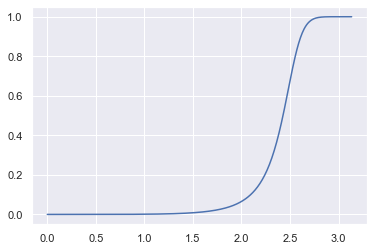

In [100]:
thetac = 0.4 * np.pi
omegac = 0.8 * np.pi
alpha = -np.cos((thetac + omegac)/2)/np.cos((thetac - omegac)/2)

Hh = K
for pk in p:
    w, Hk = signal.freqz(b=[1.0-alpha, -(1.0-alpha)], a=[1.0+alpha*pk, (pk+alpha)])
    Hh *= Hk

plt.plot(w, np.abs(Hh))
plt.show()

In [101]:
omegac

2.5132741228718345

## (4)

### (a)

設計仕様
1. 通過域端周波数$\omega_p$ [rad/sec]
2. 通過域リップル$R_p$ [dB]
3. 阻止域端周波数$\omega_s$ [rad/sec]
4. 阻止域減衰量$A_s$ [dB]


また，１と2の仕様とバタワースフィルタの振幅特性が周波数$\omega$に対して単調減少することから，

\begin{align*}
R_p &= \max_{\omega \le \omega_p} -20 \log_{10} |H(e^{j\omega})|\\
&= -20\log_{10}|H(e^{j\omega_p})|
\end{align*}

上式に教科書の式(10.1)を代入して

\begin{align*}
R_p &= 10 \log_{10} \left( 1 + \left( \frac{\tan(\omega_p/2)}{\tan(\omega_c/2)} \right)^{2N} \right)
\end{align*}

これを$\omega_c$について解くと，

\begin{align*}
\tan(\omega_c/2) &= \frac{\tan(\omega_p/2)}{(10^{Rp/10}-1)^{1/2N}}\\
\omega_c &= 2\tan^{-1}{\left( \frac{\tan(\omega_p/2)}{(10^{Rp/10}-1)^{1/2N}} \right)}\\
\end{align*}

さらに，教科書式(11.6)の$\tan(\omega_c/2)$に代入して，

\begin{align*}
A_s &= 10\log_{10}\left(1 + \left( \frac{\tan(\omega_s/2)}{\tan(\omega_p/2)} \right)^{2N}(10^{Rp/10}-1) \right)
\end{align*}

これを$N$について解くと

\begin{align*}
N &= \frac{1}{2}\frac{\log_{10}\left( \frac{10^{A_s/10}-1}{10^{R_p/10}-1} \right)}{\log_{10}\left( \frac{\tan(\omega_s/2)}{\tan(\omega_p/2)}\right)}
\end{align*}
が得られる．

### (b)

In [4]:
omegap = 0.2 * np.pi
Rp = 7.0
omegas = 0.3 * np.pi
As = 16.0

r = 10**(Rp/10) - 1.0
a = 10**(As/10) - 1.0
tanp = np.tan(omegap/2.0)
tans = np.tan(omegas/2.0)

N = np.ceil(0.5 * np.log10(a/r) / np.log10(tans/tanp))

omegac = 2.0 * np.arctan( tanp / (r**(1/(2*N))) )
print(f"N = {int(N):d}, omegac = {omegac/np.pi:.2f}pi")

N = 3, omegac = 0.16pi


## (5)

### (a)

\begin{align*}
|F(e^{j\omega})|^2 &= \frac{e^{-j\omega}-\alpha}{1-\alpha e^{-j\omega}}\frac{e^{j\omega}-\alpha}{1-\alpha e^{j\omega}}\\
&= \frac{1-2\alpha\cos\omega+\alpha^2}{1-2\alpha\cos\omega+\alpha^2}\\
&= 1
\end{align*}

### (b)

$z=e^{j\theta}$，$Z=e^{j\omega}$と置くと，

\begin{align*}
e^{-j\theta} &= \frac{e^{-j\omega}-\alpha}{1-\alpha e^{-j\omega}}.\\
\end{align*}

これを$\alpha$について解くと，
\begin{align*}
\alpha &= \frac{e^{-j\omega}-e^{-j\theta}}{1-e^{-j(\theta + \omega)}}\\
&= \frac{e^{j\frac{\theta+\omega}{2}}(e^{-j\omega} - e^{-j\theta})}
{e^{j\frac{\theta+\omega}{2}}-e^{-j\frac{\theta+\omega}{2}}}\\
&= \frac{\sin\left( \frac{\theta-\omega}{2} \right)}{\sin\left( \frac{\theta+\omega}{2} \right)}\\
&= \frac{\sin\left( \frac{\theta_c-\omega_c}{2} \right)}{\sin\left( \frac{\theta_c+\omega_c}{2} \right)}\\
\end{align*}
が得られる．したがって，$\theta=\theta_c$ならば$\omega=\omega_c$

### (c)

プロトタイプフィルタの次数を$N$，極を$p_k$と置くと，伝達関数の分母多項式は

\begin{align*}
D(z) &= \prod_{k=1}^{N}(1-p_k z^{-1})
\end{align*}
と表される．低域-低域変換を適用すると，変換後の分母多項式は

\begin{align*}
D(Z) &= \prod_{k=1}^{N}\left( 1-p_k \frac{Z^{-1}-\alpha}{1-\alpha Z^{-1}} \right)
\end{align*}
と表され，その極$P_k$は

\begin{align*}
1-p_k \frac{P_k^{-1}-\alpha}{1-\alpha P_k^{-1}} &= 0,\\
P_k &= \frac{\alpha + p_k}{1 + p_k\alpha}
\end{align*}
となる．このとき，

\begin{align*}
|P_k|^2 &= \frac{\alpha + p_k}{1 + p_k\alpha}\frac{\alpha + p_k^{*}}{1 + p_k^{*}\alpha}\\
&= \frac{\alpha^2+|p_k|^2 + 2\alpha{\rm Re}(p_k)}{1 + \alpha^2|p_k|^2 + 2\alpha{\rm Re}(p_k)}\\
\end{align*}
であり，$|p_k|<1$，$|\alpha|<1$を仮定しているので，

\begin{align*}
1 + \alpha^2|p_k|^2 - (\alpha^2 + |p_k|^2) = (1 - |p_k|^2)(1 - \alpha^2) > 0
\end{align*}

から$|P_k|<1$が得られる．したがって，変換後のディジタルフィルタも安定となる．

## (6)

### (a)

#### i
z=-Zなので，z平面の単位円を点対称に写すことになって，プロトタイプフィルタの$\pi$[rad]が変換後の0[rad]になる．
したがって，プロトタイプフィルタがLPFなら変換後はHPFになる．

#### ii
プロトタイプフィルタの$0~2\pi$が変換後は$0~\pi$に，かつiと同様に点対称に写されるので
LPFがBPFになる．

#### iii
プロトタイプフィルタの$0~2\pi$が$0~\pi$に写されるのでLPFがBSFになる．

### (b)
i. $\pi - \theta_c$

ii. $\pi/2-\theta_c/2, \pi/2+\theta_c/2$


iii. $\theta_c/2, \pi-\theta_c/2$

### (c)

プロトタイプフィルタ

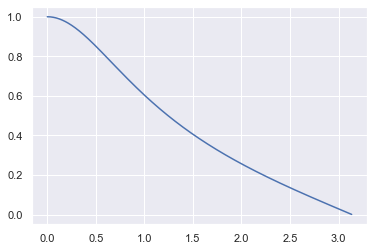

theta_c=0.7853981633974483
H(theta_c)=0.7071183572228289


In [66]:
w, Hl = signal.freqz(b=[1.0, 1.0], a=[1.0, -0.4142])
absHl = np.abs(0.2929*H)
plt.plot(w, absHl)
plt.show()

thetac = 0.25*np.pi
print(f"theta_c={thetac}")
print(f"H(theta_c)={absHl[int(len(absHl)*thetac/np.pi)]}")

高域フィルタ

\begin{align*}
H_h(Z) &= \frac{0.2929(1-Z^{-1})}{1+0.4142Z^{-1}}
\end{align*}

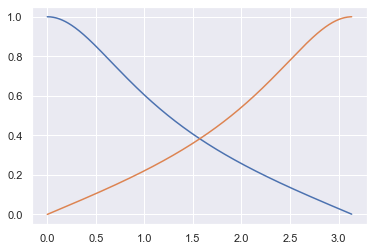

omega_c=2.356194490192345
H(omega_c)=0.7071183572228287


In [69]:
w, Hh = signal.freqz(b=[1.0, -1.0], a=[1.0, 0.4142])
absHh = np.abs(0.2929*Hh)
plt.plot(w, absHl)
plt.plot(w, absHh)
plt.show()


omegac = np.pi - thetac
print(f"omega_c={omegac}")
print(f"H(omega_c)={absHh[int(len(absHh)*omegac/np.pi)]}")

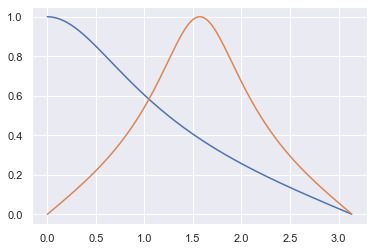

omega_cl=1.1780972450961724, omega_ch=1.9634954084936207
H(omega_cl)=0.7071183572228287
H(omega_ch)=0.7071183572228286


In [73]:
w, Hbp = signal.freqz(b=[1.0, 0.0, -1.0], a=[1.0, 0.0, 0.4142])
absHbp = np.abs(0.2929*Hbp)
plt.plot(w, absHl)
plt.plot(w, absHbp)
plt.show()

omegacl = (np.pi/2) - (thetac/2)
omegach = (np.pi/2) + (thetac/2)
print(f"omega_cl={omegacl}, omega_ch={omegach}")
print(f"H(omega_cl)={absHbp[int(len(absHbp)*omegacl/np.pi)]}")
print(f"H(omega_ch)={absHbp[int(len(absHbp)*omegach/np.pi)]}")

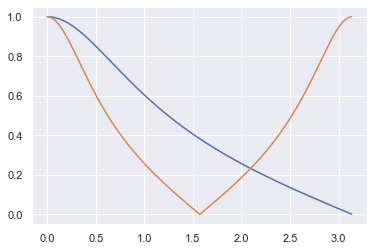

omega_cl=0.39269908169872414, omega_ch=2.748893571891069
H(omega_cl)=0.7071183572228286
H(omega_ch)=0.7071183572228287


In [77]:
w, Hbs = signal.freqz(b=[1.0, 0.0, 1.0], a=[1.0, 0.0, -0.4142])
absHbs = np.abs(0.2929*Hbs)
plt.plot(w, absHl)
plt.plot(w, absHbs)
plt.show()

omegacl = thetac/2
omegach = np.pi - (thetac/2)
print(f"omega_cl={omegacl}, omega_ch={omegach}")
print(f"H(omega_cl)={absHbs[int(len(absHbs)*omegacl/np.pi)]}")
print(f"H(omega_ch)={absHbs[int(len(absHbs)*omegach/np.pi)]}")